In [ ]:
# Instalação das bibliotecas necessárias
!pip install -q pystac-client requests geobr shapely rasterio

import requests
import geobr
import numpy as np
from pathlib import Path
from pystac_client import Client
from shapely.geometry import shape, Polygon
import zipfile
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from rasterio.warp import calculate_default_transform, reproject, Resampling


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.7/341.7 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.4 MB/s eta 0:00:00


# Download

In [ ]:

# ============================================================
# 1. AUTENTICAÇÃO ESA MAAP
# ============================================================
OFFLINE_TOKEN = "insira o token gerado na plataforma da ESA"

CLIENT_ID = "offline-token"
CLIENT_SECRET = "p1eL7uonXs6MDxtGbgKdPVRAmnGxHpVE"
TOKEN_URL = "https://iam.maap.eo.esa.int/realms/esa-maap/protocol/openid-connect/token"

data_auth = {
    "client_id": CLIENT_ID,
    "client_secret": CLIENT_SECRET,
    "grant_type": "refresh_token",
    "refresh_token": OFFLINE_TOKEN,
    "scope": "offline_access openid"
}

r = requests.post(TOKEN_URL, data=data_auth)
r.raise_for_status()
ACCESS_TOKEN = r.json()["access_token"]
print("Autenticação realizada com sucesso!")

# ============================================================
# 2. OBTER GEOMETRIA E BBOX DO DISTRITO FEDERAL (geobr)
# ============================================================
# Carrega a geometria do DF (código IBGE 53)
df_gdf = geobr.read_state(code_state=53, year=2024)

# Garante a projeção WGS84 (EPSG:4326)[cite: 1]
df_gdf = df_gdf.to_crs(epsg=4326)

# Extrai o bounding box [minx, miny, maxx, maxy]
bounds = df_gdf.total_bounds
bboxWGS84 = [float(bounds[0]), float(bounds[1]), float(bounds[2]), float(bounds[3])]
print(f"Bounding Box do DF (WGS84): {bboxWGS84}")

# Converte para polígono Shapely para cálculo posterior de sobreposição[cite: 1]
df_geom = df_gdf.geometry.unary_union

# ============================================================
# 3. CONSULTA AO CATÁLOGO STAC DO MAAP
# ============================================================
URL_LANDING_PAGE = "https://catalog.maap.eo.esa.int/catalogue/"
api = Client.open(URL_LANDING_PAGE)

results = api.search(
    method='GET',
    collections='BiomassLevel1a',
    bbox=bboxWGS84,
    filter=(
        "productType='S1_SCS__1S' "
        "or productType='S2_SCS__1S' "
        "or productType='S3_SCS__1S'"
    )
)

data = results.item_collection_as_dict()
n_found = len(data['features'])
print(f"{n_found} produtos encontrados para o Distrito Federal.")

# ============================================================
# 4. SELEÇÃO DA MELHOR CENA POR COBERTURA
# ============================================================
if n_found > 0:
    # Seleciona o produto cuja cena cobre a maior área do DF[cite: 1]
    best_idx = max(
        range(n_found),
        key=lambda i: (
            shape(data["features"][i]["geometry"])
            .intersection(df_geom)
            .area
            / df_geom.area
        )
    )

    selected_feature = data['features'][best_idx]
    file_url = selected_feature['assets']['product']['href']
    filename = selected_feature['assets']['product']['file:local_path']

    print(f"Produto selecionado: {filename}")

    # ============================================================
    # 5. DOWNLOAD DO PRODUTO SELECIONADO
    # ============================================================
    DOWNLOAD_DIR = Path("/content/biomass_df")
    DOWNLOAD_DIR.mkdir(exist_ok=True)
    outpath = DOWNLOAD_DIR / filename

    headers = {"Authorization": f"Bearer {ACCESS_TOKEN}"}

    print("Iniciando o download...")
    with requests.get(file_url, headers=headers, stream=True) as res:
        res.raise_for_status()
        with open(outpath, "wb") as f:
            for chunk in res.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

    print(f"Download concluído: {outpath}")
else:
    print("Nenhum dado encontrado para os critérios selecionados.")

Autenticação realizada com sucesso!


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'github.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'release-assets.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
states_2024_simplified.parquet: 100%|██████████| 1.79M/1.79M [00:00<00:00, 51.3MB/s]


Bounding Box do DF (WGS84): [-48.285806799999996, -16.049971399999997, -47.308494499999995, -15.501819900000006]


/tmp/ipykernel_4208/490811764.py:38: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  df_geom = df_gdf.geometry.unary_union


72 produtos encontrados para o Distrito Federal.
Produto selecionado: BIO_S2_SCS__1S_20260316T211440_20260316T211501_T_G01_M02_C05_T028_F169_01_DOEPEB.ZIP
Iniciando o download...
Download concluído: /content/biomass_df/BIO_S2_SCS__1S_20260316T211440_20260316T211501_T_G01_M02_C05_T028_F169_01_DOEPEB.ZIP


# Visualização

Descompactando: BIO_S2_SCS__1S_20260316T211440_20260316T211501_T_G01_M02_C05_T028_F169_01_DOEPEB.ZIP


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:377: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


GeoTIFF gerado com sucesso: biomass_pauli_georef.tif


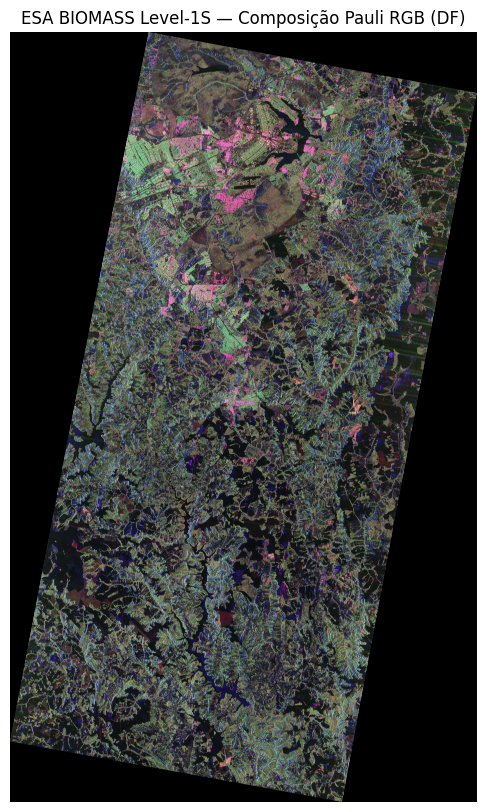

In [ ]:
# ============================================================
# 1. DESCOMPACTAÇÃO DO ARQUIVO ZIP
# ============================================================
DOWNLOAD_DIR = Path("/content/biomass_df")
EXTRACT_DIR = Path("/content/biomass_extracted")
EXTRACT_DIR.mkdir(exist_ok=True)

zip_files = list(DOWNLOAD_DIR.glob("*.ZIP")) + list(DOWNLOAD_DIR.glob("*.zip"))

if not zip_files:
    raise FileNotFoundError("Nenhum arquivo ZIP encontrado na pasta de download.")

ZIP_PATH = zip_files[0]
print(f"Descompactando: {ZIP_PATH.name}")

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

# Busca arquivos TIFF descompactados
tiff_files = list(EXTRACT_DIR.rglob("*.tiff")) + list(EXTRACT_DIR.rglob("*.tif"))

# Identifica os arquivos de Amplitude e Fase
amp_file = [f for f in tiff_files if "abs" in f.name.lower()][0]
phase_file = [f for f in tiff_files if "phase" in f.name.lower()][0]

# ============================================================
# 2. RECONSTRUÇÃO DO SINAL COMPLEXO SAR E DECOMPOSIÇÃO DE PAULI
# ============================================================
with rasterio.open(amp_file) as src_amp:
    amp_hh, amp_hv, amp_vh, amp_vv = src_amp.read(1), src_amp.read(2), src_amp.read(3), src_amp.read(4)

with rasterio.open(phase_file) as src_phase:
    phase_hh, phase_hv, phase_vh, phase_vv = src_phase.read(1), src_phase.read(2), src_phase.read(3), src_phase.read(4)

# Reconstrução do sinal complexo: S = A * exp(i * phi)
hh = amp_hh * np.exp(1j * phase_hh)
hv = amp_hv * np.exp(1j * phase_hv)
vh = amp_vh * np.exp(1j * phase_vh)
vv = amp_vv * np.exp(1j * phase_vv)

# Formulação dos canais Pauli RGB:
# Red   = |VV - HH| (Espalhamento por dupla reflexão / tronco-solo)
# Green = |HV + VH| (Espalhamento volumétrico / copa de vegetação)
# Blue  = |VV + HH| (Espalhamento de superfície / solo nu ou água)
pauli_r = np.abs(vv - hh)
pauli_g = np.abs(hv + vh)
pauli_b = np.abs(vv + hh)

# Função para normalização e estiramento de contraste via percentil
def stretch_percentile(img, p=98):
    vmax = np.nanpercentile(img, p)
    img = np.clip(img, 0, vmax)
    return img / vmax

r = stretch_percentile(pauli_r)
g = stretch_percentile(pauli_g)
b = stretch_percentile(pauli_b)

rgb = np.dstack([r, g, b])
rgb8 = np.clip(rgb * 255, 0, 255).astype(np.uint8)

# ============================================================
# 3. SALVAR IMAGEM EM GEOMETRIA DE RADAR (COM GCPs)
# ============================================================
pauli_radar_path = "biomass_pauli_radar.tif"

with rasterio.open(amp_file) as src:
    profile = src.profile.copy()
    profile.pop("nodata", None)
    profile.update(count=3, dtype="uint8", compress="deflate")
    gcps, gcp_crs = src.gcps

    with rasterio.open(pauli_radar_path, "w", **profile) as dst:
        dst.write(rgb8[:, :, 0], 1)
        dst.write(rgb8[:, :, 1], 2)
        dst.write(rgb8[:, :, 2], 3)
        dst.gcps = (gcps, gcp_crs)

# ============================================================
# 4. GEORREFERENCIAMENTO PRELIMINAR (UTM 23S / EPSG:32723)
# ============================================================
dst_crs = "EPSG:32723"

with rasterio.open(pauli_radar_path) as src:
    gcps, gcp_crs = src.gcps

    # Calcula a transformação espacial regular usando os GCPs
    transform, width, height = calculate_default_transform(
        src_crs=gcp_crs,
        dst_crs=dst_crs,
        width=src.width,
        height=src.height,
        gcps=gcps,
        resolution=10  # Resolução espacial final de 10 metros
    )

    profile_georef = src.profile.copy()
    profile_georef.update(
        crs=dst_crs,
        transform=transform,
        width=width,
        height=height
    )

    pauli_georef_path = "biomass_pauli_georef.tif"

    with rasterio.open(pauli_georef_path, "w", **profile_georef) as dst:
        for band in range(1, 4):
            reproject(
                source=rasterio.band(src, band),
                destination=rasterio.band(dst, band),
                gcps=gcps,
                src_crs=gcp_crs,
                dst_crs=dst_crs,
                dst_transform=transform,
                resampling=Resampling.cubic
            )

print(f"GeoTIFF gerado com sucesso: {pauli_georef_path}")

# ============================================================
# 5. VISUALIZAÇÃO
# ============================================================
with rasterio.open(pauli_georef_path) as georef_src:
    img_display = georef_src.read([1, 2, 3]).transpose(1, 2, 0)

plt.figure(figsize=(12, 10))
plt.imshow(img_display)
plt.title("ESA BIOMASS Level-1S — Composição Pauli RGB (DF)")
plt.axis("off")
plt.show()